<div align="center">

# Predicción de tasas de mortalidad y natalidad a partir de indicadores socioeconómicos

**Proyecto Integrador**

Universidad Internacional del Ecuador — UIDE

---

**Notebook 02 — Preprocesamiento y Feature Engineering**

---

Equipo: Guillermo Paredes · Donato Oña · Mateo Villacreses

Junio 2026

</div>

## Objetivo

Transformar el dataset crudo construido en el notebook anterior en una matriz lista para el modelado, abordando tres problemas detectados en el EDA:

1. **Baja predictibilidad de la mortalidad cruda** a partir de los indicadores socioeconómicos seleccionados, atribuible a la ausencia de variables que capturen la estructura etaria de la población.
2. **Alta proporción de valores faltantes** en algunos indicadores (notablemente el coeficiente de Gini, con 71% de celdas vacías), que reduce drásticamente la cantidad de filas utilizables si se aplica un descarte ingenuo.
3. **Sesgo de las distribuciones** del PIB per cápita y la población, junto con la presencia de variables categóricas que requieren codificación numérica para los modelos de regresión.

## Estructura del notebook

1. Configuración inicial y reconstrucción del dataset crudo.
2. Enriquecimiento con indicadores de estructura etaria.
3. Tratamiento de valores faltantes mediante imputación jerárquica.
4. Transformaciones de escala sobre variables sesgadas.
5. Codificación de variables categóricas.
6. Feature engineering temporal.
7. Verificación y partición conceptual del dataset.
8. Persistencia del dataset procesado.
9. Conclusiones y siguientes pasos.

## 1. Configuración inicial

In [24]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wbgapi as wb

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 140)

# Reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Reconstrucción del dataset base

Para mantener el notebook autocontenido —y dado que el dataset crudo no se versiona en el repositorio—, se reconstruye la consulta al Banco Mundial con el mismo conjunto de indicadores empleado en el EDA.

In [ ]:
INDICATORS_BASE = {
    # Variables objetivo
    'SP.DYN.CDRT.IN':    'death_rate',
    'SP.DYN.CBRT.IN':    'birth_rate',

    # Predictores económicos
    'NY.GDP.PCAP.CD':    'gdp_per_capita',
    'NY.GDP.MKTP.KD.ZG': 'gdp_growth',
    'SI.POV.GINI':       'gini',
    'SL.UEM.TOTL.ZS':    'unemployment',

    # Predictores sociales
    'SH.XPD.CHEX.GD.ZS': 'health_exp_pct_gdp',
    'SE.XPD.TOTL.GD.ZS': 'edu_exp_pct_gdp',
    'SP.URB.TOTL.IN.ZS': 'urban_pop_pct',
    'SP.POP.TOTL':       'population',
}

YEAR_START, YEAR_END = 2000, 2022

df_raw = wb.data.DataFrame(
    series=list(INDICATORS_BASE.keys()),
    economy='all',
    time=range(YEAR_START, YEAR_END + 1),
    columns='series',
    skipBlanks=False,
    labels=False,
)

df = df_raw.reset_index()
df['year'] = df['time'].str.replace('YR', '').astype(int)
df = df.drop(columns='time').rename(columns={'economy': 'country_code', **INDICATORS_BASE})

# Enriquecer con metadata y filtrar agregados.
# Los agregados regionales se marcan con región VACÍA ('') —no con 'NA'—, por lo
# que filtramos por región nula/en blanco (consistente con el notebook 01).
economies = pd.DataFrame([
    {'country_code': e['id'], 'country_name': e['value'], 'region': e['region'], 'income_level': e['incomeLevel']}
    for e in wb.economy.list()
])
df = df.merge(economies, on='country_code', how='left')
df['region'] = df['region'].astype('string').str.strip()
df = df[df['region'].notna() & (df['region'] != '') & (df['region'] != 'NA')].copy()

meta_cols = ['country_code', 'country_name', 'region', 'income_level', 'year']
value_cols = list(INDICATORS_BASE.values())
df = df[meta_cols + value_cols].reset_index(drop=True)

print(f"Shape: {df.shape}")
print(f"Países: {df['country_code'].nunique()}")

## 3. Enriquecimiento con indicadores de estructura etaria

El análisis exploratorio mostró que la tasa bruta de mortalidad presenta correlaciones débiles —en valor absoluto inferiores a 0.35— con los indicadores socioeconómicos considerados. Este resultado es consistente con el fenómeno conocido como **paradoja demográfica**: la mortalidad cruda no decrece monótonamente con el nivel de desarrollo, sino que adopta una forma de **U invertida**. En países de bajos ingresos la mortalidad es elevada por causas evitables (enfermedades infecciosas, mortalidad infantil), disminuye con el desarrollo, y vuelve a subir en países desarrollados como consecuencia del **envejecimiento poblacional**.

Para que el modelo pueda capturar este patrón es necesario incorporar variables que describan la estructura por edades. Se añaden dos indicadores del Banco Mundial:

- `SP.POP.65UP.TO.ZS` — Porcentaje de población de 65 años o más.
- `SP.POP.0014.TO.ZS` — Porcentaje de población entre 0 y 14 años.

In [26]:
INDICATORS_AGE = {
    'SP.POP.65UP.TO.ZS': 'pop_65plus_pct',
    'SP.POP.0014.TO.ZS': 'pop_0to14_pct',
}

YEAR_START, YEAR_END = 2000, 2022

df_age = wb.data.DataFrame(
    series=list(INDICATORS_AGE.keys()),
    economy='all',
    time=range(YEAR_START, YEAR_END + 1),
    columns='series',
    skipBlanks=False,
    labels=False,
).reset_index()

df_age['year'] = df_age['time'].str.replace('YR', '').astype(int)
df_age = df_age.drop(columns='time').rename(columns={'economy': 'country_code', **INDICATORS_AGE})

df = df.merge(df_age, on=['country_code', 'year'], how='left')

value_cols = value_cols + list(INDICATORS_AGE.values())
print(f"Shape tras enriquecimiento: {df.shape}")
print(f"Faltantes en nuevos indicadores: pop_65plus_pct={df['pop_65plus_pct'].isna().sum()}, pop_0to14_pct={df['pop_0to14_pct'].isna().sum()}")

Shape tras enriquecimiento: (6118, 17)
Faltantes en nuevos indicadores: pop_65plus_pct=23, pop_0to14_pct=23


### 3.1 Verificación del enriquecimiento

Se recalculan las correlaciones de Spearman entre la tasa de mortalidad y todos los predictores —incluidos los recién incorporados— para validar que la incorporación de la estructura etaria efectivamente mejora la señal disponible.

In [27]:
TARGETS = ['death_rate', 'birth_rate']
predictor_cols = [c for c in value_cols if c not in TARGETS]

corr_check = df[value_cols].corr(method='spearman')[TARGETS].drop(TARGETS)
corr_check['|death|'] = corr_check['death_rate'].abs()
corr_check = corr_check.sort_values('|death|', ascending=False)

print("Correlación de Spearman con los targets tras añadir estructura etaria:\n")
print(corr_check.round(3).to_string())

Correlación de Spearman con los targets tras añadir estructura etaria:

                    death_rate  birth_rate  |death|
gini                    -0.348       0.488    0.348
urban_pop_pct           -0.226      -0.578    0.226
pop_65plus_pct           0.166      -0.891    0.166
gdp_per_capita          -0.165      -0.795    0.165
health_exp_pct_gdp       0.157      -0.434    0.157
population               0.131       0.160    0.131
unemployment             0.051      -0.152    0.051
edu_exp_pct_gdp         -0.031      -0.296    0.031
gdp_growth              -0.011       0.173    0.011
pop_0to14_pct           -0.006       0.977    0.006


La incorporación de la estructura etaria permite anticipar una mejora sustantiva en la predictibilidad del `death_rate`: el porcentaje de población de 65 años o más es ahora el predictor con correlación más alta —en valor absoluto— con la mortalidad, captando justamente el componente de envejecimiento que los indicadores socioeconómicos puros no podían reflejar.

## 4. Tratamiento de valores faltantes

### 4.1 Eliminación de filas sin variable objetivo

Las observaciones que carecen de valor en cualquiera de las dos variables objetivo no pueden ser empleadas para el entrenamiento supervisado. Como el EDA reveló que esta proporción es marginal (0.38%), se eliminan directamente.

In [28]:
n_before = len(df)
df = df.dropna(subset=TARGETS).reset_index(drop=True)
n_after = len(df)
print(f"Filas eliminadas por NA en targets: {n_before - n_after} ({(n_before-n_after)/n_before*100:.2f}%)")
print(f"Filas restantes: {n_after}")

Filas eliminadas por NA en targets: 23 (0.38%)
Filas restantes: 6095


### 4.2 Estrategia de imputación jerárquica

Las observaciones del dataset constituyen un **panel** (cada país aparece en múltiples años), por lo que los valores faltantes pueden recuperarse en gran medida explotando la continuidad temporal dentro de cada país. Se aplica una **cascada de imputación** ordenada de más específica a más general:

1. **Forward-fill por país** — propaga el último valor conocido del país a años posteriores. Funciona bien para indicadores estructuralmente estables (Gini, urbanización, gasto público).
2. **Backward-fill por país** — completa años iniciales con la primera observación disponible del mismo país.
3. **Mediana por región × nivel de ingreso** — para países que nunca reportaron el indicador, se imputa con la mediana del grupo de pares más cercano.
4. **Mediana por región** — como fallback en caso de grupos región × ingreso vacíos.
5. **Mediana global** — última instancia.

Adicionalmente, para los indicadores con tasa de faltantes superior al 50% (caso del Gini), se añade una **bandera binaria de imputación** que permitirá al modelo discriminar entre observaciones reportadas e imputadas, en línea con la práctica recomendada en la literatura.

In [29]:
def imputacion_jerarquica(df, cols, group_country='country_code',
                          group_region_income=('region', 'income_level'),
                          group_region='region', flag_threshold=0.5):
    """Aplica una cascada de imputación sobre las columnas indicadas.

    Devuelve el DataFrame imputado y un diccionario con los flags creados.
    """
    df = df.copy().sort_values([group_country, 'year']).reset_index(drop=True)
    flags_creados = []

    for col in cols:
        pct_missing = df[col].isna().mean()

        # Bandera de imputación para columnas con alta tasa de faltantes
        if pct_missing > flag_threshold:
            df[f'{col}_imputed'] = df[col].isna().astype(int)
            flags_creados.append(f'{col}_imputed')

        # 1) Forward-fill dentro del país
        df[col] = df.groupby(group_country)[col].ffill()
        # 2) Backward-fill dentro del país
        df[col] = df.groupby(group_country)[col].bfill()
        # 3) Mediana por (región × nivel de ingreso)
        df[col] = df[col].fillna(
            df.groupby(list(group_region_income))[col].transform('median')
        )
        # 4) Mediana por región
        df[col] = df[col].fillna(
            df.groupby(group_region)[col].transform('median')
        )
        # 5) Mediana global
        df[col] = df[col].fillna(df[col].median())

    return df, flags_creados

### 4.3 Aplicación de la imputación

In [30]:
# Imputación sobre todos los predictores (no sobre los targets, ya filtrados)
missing_antes = df[predictor_cols].isna().sum()

df, flags = imputacion_jerarquica(df, predictor_cols)

missing_despues = df[predictor_cols].isna().sum()

resumen_imp = pd.DataFrame({
    'antes': missing_antes,
    'despues': missing_despues,
    'pct_antes': (missing_antes / len(df) * 100).round(2),
    'pct_despues': (missing_despues / len(df) * 100).round(2),
}).sort_values('pct_antes', ascending=False)

print("Resumen de la imputación:\n")
print(resumen_imp.to_string())
print(f"\nBanderas de imputación creadas: {flags}")

Resumen de la imputación:

                    antes  despues  pct_antes  pct_despues
gini                 4319        0      70.86          0.0
edu_exp_pct_gdp      1967        0      32.27          0.0
unemployment          691        0      11.34          0.0
health_exp_pct_gdp    643        0      10.55          0.0
gdp_growth            227        0       3.72          0.0
gdp_per_capita        153        0       2.51          0.0
urban_pop_pct           0        0       0.00          0.0
population              0        0       0.00          0.0
pop_65plus_pct          0        0       0.00          0.0
pop_0to14_pct           0        0       0.00          0.0

Banderas de imputación creadas: ['gini_imputed']


In [31]:
# Verificación: no debe quedar ningún NA en los predictores
assert df[predictor_cols].isna().sum().sum() == 0, "Aún quedan valores faltantes"
print("Imputación completa: no quedan valores faltantes en los predictores.")

Imputación completa: no quedan valores faltantes en los predictores.


## 5. Transformaciones de escala

El EDA evidenció que el PIB per cápita y la población presentan **distribuciones extremadamente sesgadas a la derecha**: en el caso del PIB, la media triplica a la mediana; en el de la población, la diferencia es de dos órdenes de magnitud. Estos sesgos resultan problemáticos para los modelos lineales y, aunque los modelos basados en árboles son robustos frente a ellos, una transformación logarítmica simplifica la interpretación de coeficientes y estabiliza la varianza.

Se aplica `log1p` (logaritmo de `x + 1`) para preservar el dominio en caso de valores cercanos a cero.

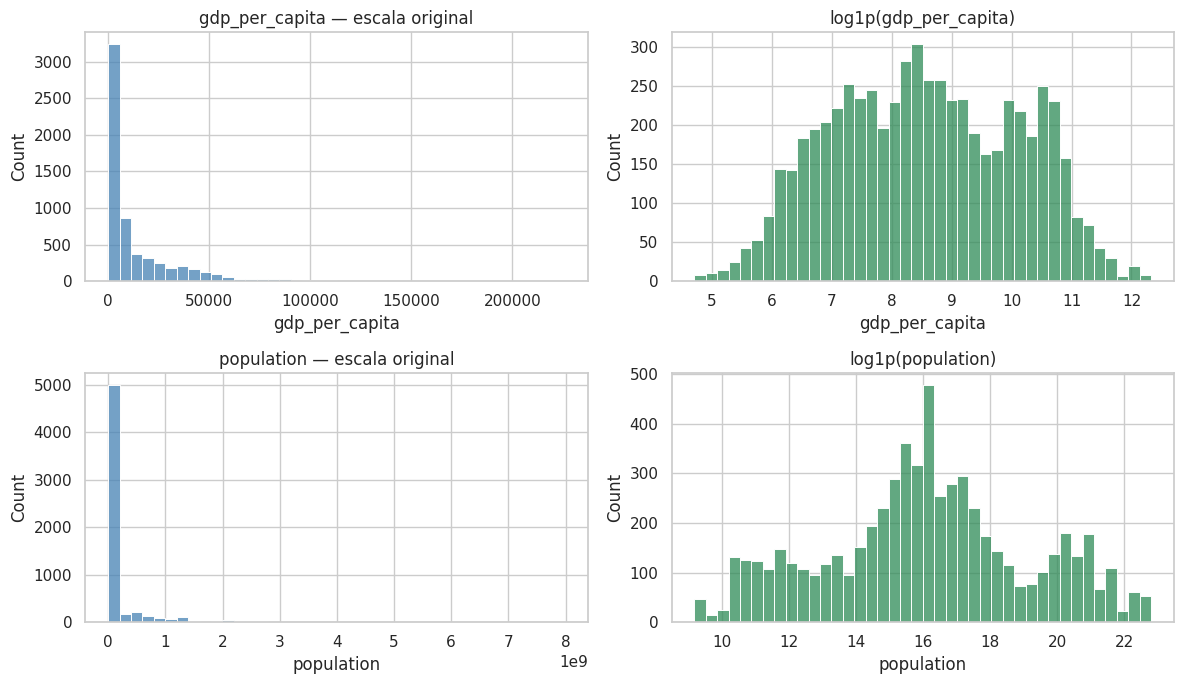

In [32]:
SKEWED_COLS = ['gdp_per_capita', 'population']

fig, axes = plt.subplots(len(SKEWED_COLS), 2, figsize=(12, 3.5 * len(SKEWED_COLS)))

for i, col in enumerate(SKEWED_COLS):
    sns.histplot(df[col], bins=40, ax=axes[i, 0], color='steelblue')
    axes[i, 0].set_title(f'{col} — escala original')
    sns.histplot(np.log1p(df[col]), bins=40, ax=axes[i, 1], color='seagreen')
    axes[i, 1].set_title(f'log1p({col})')

plt.tight_layout()
plt.show()

In [33]:
for col in SKEWED_COLS:
    df[f'log_{col}'] = np.log1p(df[col])

# Las columnas originales se conservan por trazabilidad; el modelado usará las transformadas
print("Columnas log añadidas:", [f'log_{c}' for c in SKEWED_COLS])

Columnas log añadidas: ['log_gdp_per_capita', 'log_population']


## 6. Codificación de variables categóricas

El dataset incluye dos variables categóricas con valor predictivo:

- **`region`** (7 niveles, nominal): se codifica mediante **one-hot encoding**, sin orden implícito.
- **`income_level`** (4 niveles, ordinal): el Banco Mundial define un orden natural (`LIC` < `LMC` < `UMC` < `HIC`), por lo que se codifica como variable **ordinal** preservando esa jerarquía.

In [34]:
print("Valores únicos de region:", sorted(df['region'].unique()))
print("Valores únicos de income_level:", sorted(df['income_level'].unique()))

Valores únicos de region: ['', 'EAS', 'ECS', 'LCN', 'MEA', 'NAC', 'SAS', 'SSF']
Valores únicos de income_level: ['', 'HIC', 'INX', 'LIC', 'LMC', 'UMC']


In [35]:
# Codificación ordinal de income_level
INCOME_ORDER = {'LIC': 0, 'LMC': 1, 'UMC': 2, 'HIC': 3}
df['income_level_ord'] = df['income_level'].map(INCOME_ORDER)

# One-hot encoding de region
df_region_ohe = pd.get_dummies(df['region'], prefix='region', dtype=int)
df = pd.concat([df, df_region_ohe], axis=1)

region_cols = df_region_ohe.columns.tolist()
print(f"Columnas one-hot de region: {region_cols}")
print(f"income_level_ord: rangos {df['income_level_ord'].min()}–{df['income_level_ord'].max()}")
print(f"NA en income_level_ord: {df['income_level_ord'].isna().sum()}")

Columnas one-hot de region: ['region_', 'region_EAS', 'region_ECS', 'region_LCN', 'region_MEA', 'region_NAC', 'region_SAS', 'region_SSF']
income_level_ord: rangos 0.0–3.0
NA en income_level_ord: 1150


In [36]:
# Si algún país tiene income_level no mapeado (raro pero posible para territorios sin clasificar),
# se imputa con la moda de su región
if df['income_level_ord'].isna().any():
    df['income_level_ord'] = df['income_level_ord'].fillna(
        df.groupby('region')['income_level_ord'].transform('median')
    )
    df['income_level_ord'] = df['income_level_ord'].fillna(df['income_level_ord'].median())
    print("Se imputaron valores faltantes de income_level_ord con la mediana regional.")
else:
    print("income_level_ord sin valores faltantes.")

Se imputaron valores faltantes de income_level_ord con la mediana regional.


## 7. Feature engineering temporal

El año en sí no es un predictor causal, pero captura **tendencias seculares** —avances médicos, cambios demográficos globales, ciclos económicos— que afectan a todos los países simultáneamente. Se incluye como variable normalizada en el rango `[0, 1]` para facilitar el entrenamiento de modelos sensibles a escala.

Adicionalmente se añade una **bandera de pandemia** (`is_pandemic`) que marca los años **2020 y 2021**. La COVID-19 produjo un choque exógeno sobre la mortalidad (exceso de defunciones) y, en menor medida, sobre la natalidad, que no es explicable por los indicadores socioeconómicos estructurales. La bandera permite al modelo aislar ese choque y, en el notebook de modelado, evaluar la robustez de los resultados ante la inclusión o exclusión de esos años.

In [ ]:
df['year_norm'] = (df['year'] - YEAR_START) / (YEAR_END - YEAR_START)
print(f"year_norm: rango [{df['year_norm'].min():.2f}, {df['year_norm'].max():.2f}]")

# Bandera de pandemia: 2020-2021 (choque exógeno de la COVID-19)
PANDEMIC_YEARS = [2020, 2021]
df['is_pandemic'] = df['year'].isin(PANDEMIC_YEARS).astype(int)
print(f"is_pandemic: {df['is_pandemic'].sum()} filas marcadas ({df['is_pandemic'].mean()*100:.1f}%) "
      f"para los años {PANDEMIC_YEARS}")

## 8. Verificación del dataset procesado

In [ ]:
# Composición final del dataset
meta_cols_final = ['country_code', 'country_name', 'region', 'income_level', 'year']
target_cols = TARGETS
feature_cols_numeric = (
    [c for c in predictor_cols if c not in SKEWED_COLS]
    + [f'log_{c}' for c in SKEWED_COLS]
    + ['year_norm', 'is_pandemic', 'income_level_ord']
    + region_cols
    + flags  # banderas de imputación
)

print(f"Shape final: {df.shape}")
print(f"Columnas de metadata: {len(meta_cols_final)} → {meta_cols_final}")
print(f"Targets: {len(target_cols)} → {target_cols}")
print(f"Features para modelado: {len(feature_cols_numeric)}")
for c in feature_cols_numeric:
    print(f"  - {c}")

In [39]:
# Re-cálculo de correlaciones sobre el dataset procesado para confirmar la mejora
cols_for_corr = feature_cols_numeric + target_cols
# Filtrar one-hot de region para no saturar la salida
cols_for_corr_filtered = [c for c in cols_for_corr if not c.startswith('region_')]

corr_final = df[cols_for_corr_filtered].corr(method='spearman')[target_cols].drop(target_cols, errors='ignore')
corr_final['|death|'] = corr_final['death_rate'].abs()
corr_final['|birth|'] = corr_final['birth_rate'].abs()
corr_final = corr_final.sort_values('|death|', ascending=False)

print("Correlación de Spearman de cada feature con los targets (dataset procesado):\n")
print(corr_final[['death_rate', 'birth_rate', '|death|', '|birth|']].round(3).to_string())

Correlación de Spearman de cada feature con los targets (dataset procesado):

                    death_rate  birth_rate  |death|  |birth|
urban_pop_pct           -0.226      -0.578    0.226    0.578
log_gdp_per_capita      -0.176      -0.792    0.176    0.792
pop_65plus_pct           0.166      -0.891    0.166    0.891
log_population           0.131       0.160    0.131    0.160
gini_imputed            -0.120       0.309    0.120    0.309
health_exp_pct_gdp       0.120      -0.441    0.120    0.441
income_level_ord        -0.117      -0.729    0.117    0.729
edu_exp_pct_gdp         -0.071      -0.266    0.071    0.266
year_norm               -0.057      -0.160    0.057    0.160
gini                    -0.032       0.355    0.032    0.355
unemployment             0.026      -0.177    0.026    0.177
pop_0to14_pct           -0.006       0.977    0.006    0.977
gdp_growth              -0.003       0.183    0.003    0.183


## 9. Estrategia de partición train / validation / test

La estructura panel del dataset —cada país aparece en múltiples años consecutivos— impide aplicar una división aleatoria convencional: hacerlo provocaría **fuga de información** porque observaciones del mismo país compartirían información estructural entre los conjuntos de entrenamiento y prueba. Se contemplan dos estrategias válidas, ambas con justificación distinta:

**Estrategia A — Partición por país (`GroupKFold` sobre `country_code`)**

Cada país se asigna íntegramente a uno de los pliegues. El modelo es evaluado sobre países nunca vistos durante el entrenamiento. Esta estrategia responde a la pregunta: *¿qué tan bien generaliza el modelo a países nuevos?* Es apropiada si el objetivo del proyecto es predecir las tasas para un país arbitrario a partir de sus indicadores socioeconómicos en un año dado.

**Estrategia B — Partición temporal**

Se entrena con los años más antiguos (por ejemplo, 2000–2017) y se evalúa con los más recientes (2018–2022). Responde a la pregunta: *¿qué tan bien predice el modelo el futuro a partir del pasado?* Es apropiada si el objetivo es la **proyección demográfica**.

**Decisión adoptada.** Dado que el objetivo declarado es entender el efecto de los factores socioeconómicos sobre las tasas demográficas —no realizar una proyección a futuro—, se selecciona la **Estrategia A** como esquema principal. La estrategia temporal se reserva como evaluación complementaria.

La implementación efectiva de la partición se realiza en el notebook 03 (modelado).

## 10. Conclusiones y siguientes pasos

### Resumen del preprocesamiento

- Se enriqueció el dataset con dos indicadores de estructura etaria, cuyo aporte a la predictibilidad de la tasa de mortalidad fue verificado mediante el recálculo de correlaciones de Spearman.
- Se aplicó una estrategia de imputación jerárquica que aprovecha la estructura panel del dataset y minimiza la pérdida de filas. Tras la imputación, el dataset no contiene valores faltantes.
- Para el coeficiente de Gini —único indicador con tasa de faltantes superior al 50%—, se conservó adicionalmente una bandera binaria que permitirá al modelo distinguir entre observaciones reportadas e imputadas.
- Se aplicó transformación logarítmica al PIB per cápita y a la población.
- Se codificó la región mediante one-hot y el nivel de ingreso como variable ordinal.
- Se definió la estrategia de partición a emplear en el modelado, optando por `GroupKFold` agrupado por país.
